![Getaround](https://lever-client-logos.s3.amazonaws.com/2bd4cdf9-37f2-497f-9096-c2793296a75f-1568844229943.png)

# What should a car rent for?

The brief asks for a pricing model served at `/predict`: given a car and its options, suggest a daily rental
price. This notebook is where that model was studied — what to clean, which family of models is
worth serving, and what the winner actually knows.

---

### How this notebook is organised

| Section | What it does |
|---|---|
| 1 | The pricing model: cleaning, four models compared, what the winner knows |
| 2 | What ships |

Every claim below is the output of the cell above it.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# Plotly figures are rendered as static images rather than interactive widgets.
# Reason: this notebook has to stay readable wherever it is opened.
# GitHub, nbviewer and PDF exports all strip interactive plotly output and would show nothing.
pio.renderers.default = 'png'

# Charts are also written to disk, so the README can reuse them.
IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

# One seed for the whole notebook: the train/test split, every model fit and the grid search
# read it, so every number below is reproducible from this line.
RANDOM_STATE = 42

# The palette: one blue for a single measure, blue/red when a chart carries a contrast.
BLUE, RED = '#2a78d6', '#e34948'


def show(fig, name, height=520):
    """Render a figure in the notebook and save it as a PNG under images/."""
    fig.update_layout(width=980, height=height, template='plotly_white',
                      margin=dict(t=80, b=60, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show()


pricing = pd.read_csv('data/get_around_pricing_project.csv').drop(columns=['Unnamed: 0'])
print(f'pricing file: {pricing.shape[0]:,} cars x {pricing.shape[1]} columns'.replace(',', ' '))
pricing.head()

pricing file: 4 843 cars x 14 columns


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


## 1. The pricing model behind `/predict`

The brief asks for a pricing recommendation the API serves: given a car, suggest a
daily price. 4 843 cars, thirteen features, one target.

### 1.1 What the file holds, and the two rows removed

In [2]:
# One line per column: the type pandas read, the missing values, the distinct values.
overview = pd.DataFrame({'dtype': pricing.dtypes.astype(str), 'missing': pricing.isna().sum(),
                         'distinct': pricing.nunique()})
print(overview.to_string())
print(f'\nduplicated rows: {pricing.duplicated().sum()}')

                            dtype  missing  distinct
model_key                  object        0        28
mileage                     int64        0      4786
engine_power                int64        0        61
fuel                       object        0         4
paint_color                object        0        10
car_type                   object        0         8
private_parking_available    bool        0         2
has_gps                      bool        0         2
has_air_conditioning         bool        0         2
automatic_car                bool        0         2
has_getaround_connect        bool        0         2
has_speed_regulator          bool        0         2
winter_tires                 bool        0         2
rental_price_per_day        int64        0       220

duplicated rows: 0


Nothing to convert and nothing to impute. pandas read every column as the type it is — integers
for the two measures and the price, text for the four categories, booleans for the seven options —
and the file has no missing value and no duplicated row.

In [3]:
# The three numeric columns; the edges of each are where a wrong value shows.
print(pricing.describe().round(0).to_string())

         mileage  engine_power  rental_price_per_day
count     4843.0        4843.0                4843.0
mean    140963.0         129.0                 121.0
std      60197.0          39.0                  34.0
min        -64.0           0.0                  10.0
25%     102914.0         100.0                 104.0
50%     141080.0         120.0                 119.0
75%     175196.0         135.0                 136.0
max    1000376.0         423.0                 422.0


The quartiles are ordinary; the edges are not. Three values stand out: a mileage of **−64 km**, an
engine of **0 hp**, and a mileage of **1 000 376 km**. The price runs from €10 to €422; its low end is looked at
further down.

In [4]:
# The five lowest and the five highest values of each column: what sits at the edges.
edges = pd.DataFrame({
    f'{column}, {side}': (pricing[column].nsmallest(5) if side == 'lowest'
                          else pricing[column].nlargest(5).iloc[::-1]).to_numpy()
    for column in ['mileage', 'engine_power'] for side in ['lowest', 'highest']})
print(edges.to_string(index=False))

 mileage, lowest  mileage, highest  engine_power, lowest  engine_power, highest
             -64            405816                     0                    317
             476            439060                    25                    317
             612            477571                    25                    317
             706            484615                    66                    412
            2399           1000376                    66                    423


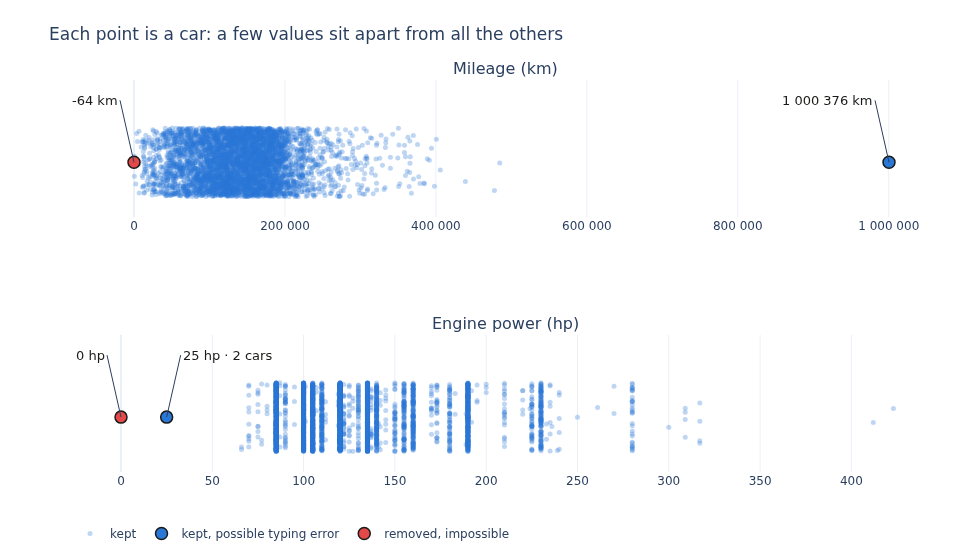

In [5]:
from plotly.subplots import make_subplots

# Impossible: a value no car can have. Doubtful: possible, but apart from every other car --
# the highest mileage and the lowest engine power once the impossible rows are set aside.
impossible = (pricing['mileage'] < 0) | (pricing['engine_power'] == 0)
far_mileage = pricing['mileage'] == pricing['mileage'].max()
low_power = pricing['engine_power'] == pricing.loc[~impossible, 'engine_power'].min()
doubtful = far_mileage | low_power

# One point per car. The vertical spread is random: it only keeps the points from piling up.
rng = np.random.default_rng(RANDOM_STATE)
fig = make_subplots(rows=2, cols=1, vertical_spacing=0.3,
                    subplot_titles=['Mileage (km)', 'Engine power (hp)'])
for row, (column, unit) in enumerate([('mileage', 'km'), ('engine_power', 'hp')], start=1):
    values = pricing[column]
    span = values.max() - values.min()
    ordinary = ~(impossible | doubtful)
    fig.add_trace(go.Scatter(
        x=values[ordinary], y=rng.uniform(-1, 1, ordinary.sum()), mode='markers',
        marker=dict(color=BLUE, size=5, opacity=0.3), name='kept',
        showlegend=row == 1), row=row, col=1)
    groups = [(doubtful, BLUE, 'kept, possible typing error'), (impossible, RED, 'removed, impossible')]
    marked = sorted(set(values[impossible | doubtful]))
    for mask, color, name in groups:
        apart = values[mask].value_counts().sort_index()
        # A marked value that is ordinary in this column (the -64 km car has a normal engine)
        # is not singled out here.
        apart = apart[[v == values.min() or v == values.max() or (mask & (values == v)).sum() > 1
                       for v in apart.index]]
        fig.add_trace(go.Scatter(
            x=apart.index, y=[0] * len(apart), mode='markers', name=name, showlegend=row == 1,
            marker=dict(color=color, size=12, line=dict(color='#1a1a19', width=1.5))),
            row=row, col=1)
        for value, cars in apart.items():
            neighbours = [m for m in marked if m != value and abs(m - value) < 0.1 * span]
            to_the_left = value > values.median() or (neighbours and value < min(neighbours))
            label = f'{value:,} {unit}'.replace(',', ' ') + (f' · {cars} cars' if cars > 1 else '')
            fig.add_annotation(x=value, y=0, text=label, showarrow=True, arrowhead=0, arrowwidth=1,
                               ax=-14 if to_the_left else 14, ay=-62,
                               xanchor='right' if to_the_left else 'left',
                               font=dict(size=13, color='#1a1a19'), row=row, col=1)
    fig.update_yaxes(visible=False, range=[-1.6, 2.4], row=row, col=1)
    fig.update_xaxes(tickformat=',d', row=row, col=1)
fig.update_layout(title='Each point is a car: a few values sit apart from all the others',
                  separators='. ', legend=dict(orientation='h', y=-0.12, x=0))
show(fig, '1_values_apart', height=560)

The table and the chart show the same edges from two sides.

- **Mileage.** −64 km sits at the left edge, next to cars with a few hundred kilometres: the chart
  cannot set it apart, its sign does. 1 000 376 km is alone, the next car being at 484 615 km.
- **Engine power.** 0 hp is alone at the left. Two cars at 25 hp follow, then nothing until 66 hp.

So there are two kinds of values here: two that no car can have, in red, and three that a car can
have but that sit apart from every other car, outlined.

In [6]:
COLUMNS = ['model_key', 'mileage', 'engine_power', 'fuel', 'car_type', 'rental_price_per_day']
price = pricing['rental_price_per_day']

print(f'removed as impossible: {impossible.sum()} rows of {len(pricing):,} = {impossible.mean():.2%}'
      .replace(',', ' '))
print(pricing.loc[impossible, COLUMNS].to_string(index=False))

# For each doubtful car, where its price sits: the share of all cars that rent for less.
kept = pricing.loc[doubtful, COLUMNS].copy()
kept['cheaper cars'] = [f'{(price < p).mean():.0%}' for p in kept['rental_price_per_day']]
print(f'\nkept as possible typing errors: {doubtful.sum()} rows')
print(kept.to_string(index=False))

same_brand = pricing['model_key'].isin(pricing.loc[low_power, 'model_key']) & ~low_power
print('\nthe other cars of the low-power brand:')
print(pricing.loc[same_brand, COLUMNS].sort_values('engine_power').to_string(index=False))

print(f'\nprice below 25 EUR/day: {(price < 25).sum()} cars '
      f'-> {sorted(int(p) for p in price[price < 25].unique())}')

removed as impossible: 2 rows of 4 843 = 0.04%
model_key  mileage  engine_power   fuel car_type  rental_price_per_day
  Renault      -64           230 diesel    sedan                   274
   Nissan    81770             0 diesel      suv                   108

kept as possible typing errors: 3 rows
model_key  mileage  engine_power          fuel   car_type  rental_price_per_day cheaper cars
  Porsche   152328            25 hybrid_petrol  hatchback                   142          80%
  Porsche   152470            25 hybrid_petrol  hatchback                   124          58%
  Citroën  1000376            90        diesel subcompact                    37           2%

the other cars of the low-power brand:
model_key  mileage  engine_power          fuel   car_type  rental_price_per_day
  Porsche    26542            75       electro  hatchback                   145
  Porsche    78740            75       electro  hatchback                   144
  Porsche     6572            75 hybrid_petrol s

**Only the two impossible rows are removed**: a mileage cannot be negative, and an engine cannot
have zero power. That is 0.04% of the file, too small to change a score: the reason is that serving
a prediction fitted on such values is indefensible, not that it helps.

**Three rows are kept and named as possible typing errors.** These are hypotheses, and the file
cannot confirm either:

- **1 000 376 km** may be 100 376 with one digit too many. The car rents for €37 a day, less than
  98% of the fleet.
- **25 hp**, twice, may be 250 with a zero missing. Both cars rent for more than most of the fleet —
  €142 and €124 — which is a high price for the two least powerful cars in the file. But the four
  other cars of that brand, at 75 to 125 hp, rent for €144 to €167: here the price follows the
  brand as much as the engine, so it does not settle the question.

They stay because a possible value cannot be told from a wrong one in this file, and removing a row
on a guess would be choosing the data. The eighteen cars priced under €25 a day stay for the same
reason: ten euros is a strange price, not an impossible one, and this is a model of what owners
*do* charge.

In [7]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import (GridSearchCV, KFold, cross_val_score, cross_validate,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

clean = pricing[~impossible].reset_index(drop=True)
NUMERIC = ['mileage', 'engine_power']
CATEGORICAL = ['model_key', 'fuel', 'paint_color', 'car_type']
BOOLEAN = ['private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car',
           'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
FEATURES = NUMERIC + CATEGORICAL + BOOLEAN
TARGET = 'rental_price_per_day'

X, y = clean[FEATURES], clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# handle_unknown matters here for a reason that is not statistical: the endpoint is public and
# will be sent model_key values that were never in the training set. Unknown levels have to be
# encoded, not raise.
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10,
                          sparse_output=False), CATEGORICAL),
    ('bool', 'passthrough', BOOLEAN),
])
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
print(f'train {len(X_train):,} cars | test {len(X_test):,} cars'.replace(',', ' '),
      f'| price {y.min()}-{y.max()} EUR, median {y.median():.0f} EUR')

train 3 872 cars | test 969 cars | price 10-422 EUR, median 119 EUR


### 1.2 Four models, and what each is worth

In [8]:
CANDIDATES = {
    'the median price of every car': DummyRegressor(strategy='median'),
    'linear regression': LinearRegression(),
    'random forest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'gradient boosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}
rows = []
for name, estimator in CANDIDATES.items():
    pipe = Pipeline([('pre', preprocessor), ('model', estimator)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    # MAE is the criterion, in euros; R2 is kept beside it as a second reading.
    row = {'model': name, 'CV MAE': -scores['test_mae'].mean(),
           'CV MAE std': scores['test_mae'].std(), 'CV R2': scores['test_r2'].mean(),
           'test MAE': mean_absolute_error(y_test, pred), 'test R2': r2_score(y_test, pred)}
    rows.append(row)

leaderboard = pd.DataFrame(rows)
print(leaderboard.to_string(index=False, float_format='{:.3f}'.format))

by_model = leaderboard.set_index('model')
print(f"\ngradient boosting minus random forest, CV MAE: "
      f"{by_model.loc['gradient boosting', 'CV MAE'] - by_model.loc['random forest', 'CV MAE']:+.2f} EUR")

                        model  CV MAE  CV MAE std  CV R2  test MAE  test R2
the median price of every car  23.613       0.467 -0.006    23.487   -0.000
            linear regression  12.355       0.487  0.695    12.184    0.706
                random forest  10.705       0.420  0.749    10.704    0.741
            gradient boosting  10.734       0.428  0.757    10.730    0.742

gradient boosting minus random forest, CV MAE: +0.03 EUR


Charging every car the median €119 is wrong by **€23.49 on average**. The linear model nearly
halves that to €12.18, and the two ensembles take about another €1.50 off it.

The criterion is the **cross-validated MAE**, the one `training/train.py` uses: it reads in euros,
and it is measured on the training split only. On it the two ensembles are **tied**: the default
gradient boosting is €0.03 behind the random forest, when a model's MAE moves by €0.42 to €0.49
from one fold to the next.

Both ensembles are tuned below, each on its own grid, so that neither is compared tuned against
the other untuned.

In [9]:
# Each ensemble gets its own grid, scored on the same folds with the same criterion.
GRIDS = {
    'random forest': (
        RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
        {'model__max_features': [1.0, 0.5, 'sqrt'], 'model__min_samples_leaf': [1, 3, 5],
         'model__max_depth': [None, 20]}),
    'gradient boosting': (
        HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        {'model__learning_rate': [0.05, 0.1], 'model__max_iter': [200, 400],
         'model__max_leaf_nodes': [15, 31, 63], 'model__min_samples_leaf': [10, 20, 40]}),
}
searches, rows = {}, []
for name, (estimator, grid) in GRIDS.items():
    search = GridSearchCV(Pipeline([('pre', preprocessor), ('model', estimator)]), grid,
                          cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    searches[name] = search.fit(X_train, y_train)
    pred = search.best_estimator_.predict(X_test)
    print(f'{name}, best of {len(search.cv_results_["params"])}:',
          {k.replace('model__', ''): v for k, v in search.best_params_.items()})
    rows.append({'model': name, 'CV MAE': -search.best_score_,
                 'CV MAE std': search.cv_results_['std_test_score'][search.best_index_],
                 'gain from tuning': by_model.loc[name, 'CV MAE'] + search.best_score_,
                 'test MAE': mean_absolute_error(y_test, pred),
                 'median error': np.median(np.abs(y_test - pred))})

tuned = pd.DataFrame(rows).set_index('model')
print()
print(tuned.to_string(float_format='{:.2f}'.format))

# The rule, fixed before looking: the lowest cross-validated MAE is the model that ships.
winner, runner_up = tuned['CV MAE'].idxmin(), tuned['CV MAE'].idxmax()
best = searches[winner].best_estimator_
print(f'\nwinner on CV MAE : {winner}, '
      f'{tuned.loc[runner_up, "CV MAE"] - tuned.loc[winner, "CV MAE"]:.2f} EUR ahead of the {runner_up}')
print(f'on the test set  : {tuned["test MAE"].idxmin()} ahead, by '
      f'{tuned["test MAE"].max() - tuned["test MAE"].min():.2f} EUR')
print(f'median price of the test cars: {y_test.median():.0f} EUR')

random forest, best of 18: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1}


gradient boosting, best of 36: {'learning_rate': 0.1, 'max_iter': 200, 'max_leaf_nodes': 15, 'min_samples_leaf': 10}

                   CV MAE  CV MAE std  gain from tuning  test MAE  median error
model                                                                          
random forest       10.42        0.35              0.29     10.61          6.77
gradient boosting   10.50        0.43              0.24     10.48          6.62

winner on CV MAE : random forest, 0.08 EUR ahead of the gradient boosting
on the test set  : gradient boosting ahead, by 0.13 EUR
median price of the test cars: 119 EUR


Tuning helps both by about the same amount: €0.29 for the random forest over 18 combinations, €0.24
for the gradient boosting over 36.

**The random forest ends €0.08 ahead on cross-validated MAE, and it is the model that ships**: the
rule, fixed before looking at the result, is the lowest cross-validated MAE. It is not a clear win.
The gap is a fraction of the fold-to-fold spread of either model, and the test set ranks the two
the other way round, by €0.13. These two models are tied; the rule only breaks the tie the same
way every time.

The model that ships is wrong by **€10.61 on average, on a median price of €119**, and half the
cars are priced within **€6.77**.

### 1.3 The price is the car, not the equipment

In [10]:
GROUPS = {
    'everything (13 features)': (NUMERIC, CATEGORICAL, BOOLEAN),
    'the car only — engine, mileage, model, fuel, type': (NUMERIC, ['model_key', 'fuel', 'car_type'], []),
    'the options only — 7 booleans and the colour': ([], ['paint_color'], BOOLEAN),
    'engine_power alone': (['engine_power'], [], []),
}
for label, (num, cat, boo) in GROUPS.items():
    steps = ([('num', StandardScaler(), num)] if num else [])
    steps += ([('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10,
                                     sparse_output=False), cat)] if cat else [])
    steps += ([('bool', 'passthrough', boo)] if boo else [])
    pipe = Pipeline([('pre', ColumnTransformer(steps)),
                     ('model', clone(best.named_steps['model']))])   # the winning model
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)
    print(f'{label:<52} CV R2 {s.mean():.3f} +/-{s.std():.3f}')

everything (13 features)                             CV R2 0.759 +/-0.050


the car only — engine, mileage, model, fuel, type    CV R2 0.708 +/-0.050


the options only — 7 booleans and the colour         CV R2 0.328 +/-0.047


engine_power alone                                   CV R2 0.473 +/-0.029


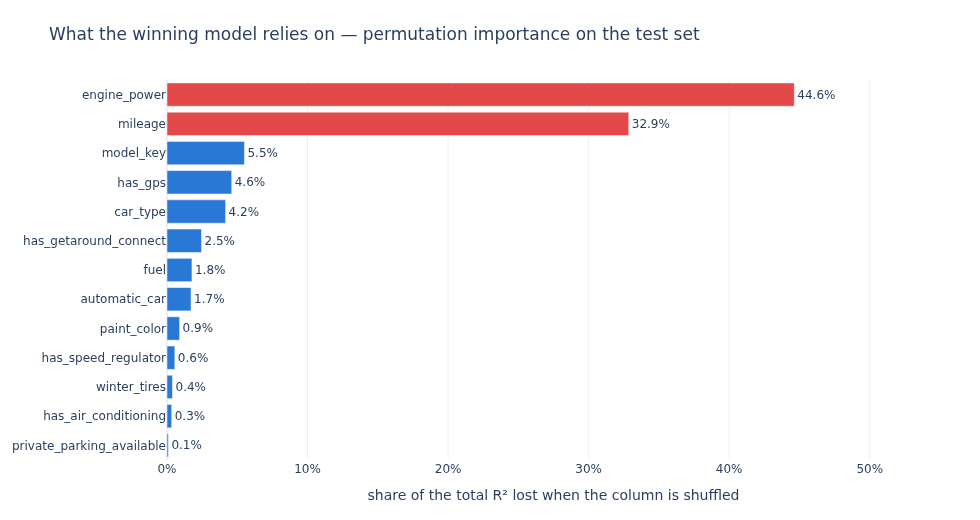

engine_power                 44.6
mileage                      32.9
model_key                     5.5
has_gps                       4.6
car_type                      4.2
has_getaround_connect         2.5
fuel                          1.8
automatic_car                 1.7
paint_color                   0.9
has_speed_regulator           0.6
winter_tires                  0.4
has_air_conditioning          0.3
private_parking_available     0.1

engine_power + mileage    : 77.5%
the 7 options + the colour: 11.1%


In [11]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring='r2')
importance = (pd.Series(perm.importances_mean, index=FEATURES)
              .sort_values() / perm.importances_mean.sum())
fig = go.Figure(go.Bar(
    x=importance.values, y=importance.index, orientation='h',
    marker_color=[RED if f in NUMERIC else BLUE for f in importance.index],
    text=[f'{v:.1%}' for v in importance.values], textposition='outside',
))
fig.update_layout(
    title='What the winning model relies on — permutation importance on the test set',
    xaxis=dict(title='share of the total R² lost when the column is shuffled', tickformat='.0%',
               range=[0, 0.55]),
    yaxis=dict(title=None), showlegend=False,
)
show(fig, '4_feature_importance', height=520)
print(importance.sort_values(ascending=False).mul(100).round(1)
      .rename('% of the total drop').to_string())
print(f'\nengine_power + mileage    : {importance[NUMERIC].sum():.1%}')
print(f"the 7 options + the colour: {importance[BOOLEAN + ['paint_color']].sum():.1%}")

**The two columns an owner cannot change carry 77.5% of the model.** `engine_power` alone is 44.6%
of it and `mileage` 32.9%; the seven equipment booleans and the paint colour together are 11.1%.

Fitted on the car's own characteristics only, the model reaches **CV R² 0.708**. Adding everything
the owner controls — GPS, air conditioning, automatic gearbox, Connect, speed regulator, winter
tyres, private parking, colour — takes it to **0.759**, about five points. Those same options
fitted *alone* reach 0.328.

`/predict` estimates the market price of a car as it is. It cannot tell an owner how to raise that
price: the options an owner could add weigh little in the model, and the engine and the mileage
cannot be changed. The brief speaks of pricing optimisation; what this model provides is a price
estimate.

In [12]:
# The model that ships is the winner, refitted on every car, train and test together.
final = clone(best).fit(X, y)

sample = X.head(2).values.tolist()
print('the pipeline training/train.py fits, refitted on all',
      f'{len(X):,} cars'.replace(',', ' '))
print(f'  steps        : {[name for name, _ in final.steps]}')
print(f'  feature order: {FEATURES}')
print(f'\nthe endpoint contract, checked here so the API cannot disagree with the notebook:')
print(f'  input      : {json.dumps({"input": sample})[:108]}...')
print(f'  prediction : {[round(float(v), 2) for v in final.predict(X.head(2))]} EUR/day')

the pipeline training/train.py fits, refitted on all 4 841 cars
  steps        : ['pre', 'model']
  feature order: ['mileage', 'engine_power', 'model_key', 'fuel', 'paint_color', 'car_type', 'private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']

the endpoint contract, checked here so the API cannot disagree with the notebook:
  input      : {"input": [[140411, 100, "Citro\u00ebn", "diesel", "black", "convertible", true, true, false, false, true, t...
  prediction : [110.21, 239.31] EUR/day


This notebook stops here, one step short of an artefact. **The model that ships is fitted and
registered by [`training/train.py`](training/train.py)**, which replays this comparison in MLflow
— one run per candidate, both grids included — and registers the winner as
`challenger`. [`training/promote.py`](training/promote.py) moves `champion` to it only after a
review, and only if its held-out MAE is lower. The API resolves
`models:/getaround-pricing-model@champion` at startup, so promoting a better model is an alias
move rather than a redeployment.

Two properties of that split are worth stating. What gets logged is **the whole pipeline** —
scaler, encoder and regressor — so the API owns no feature engineering and only ever calls
`.predict(...)`; the column order and the column types it enforces come from the logged signature
rather than from a list written twice. And the registered model is **refitted on all 4 841 cars**,
train and test together: the split existed to choose the model, and once chosen there is no reason
to serve a version trained on 80% of the data.

The two prices printed above are the check that keeps the notebook and the endpoint honest: the
deployed `/predict` returns the same two numbers for the same two cars.

## 2. What ships

**1. A random forest, chosen in MLflow by a rule fixed in advance.** `training/train.py` evaluates
every candidate of section 1.2 as its own run, picks the lowest cross-validated MAE and registers
it as `challenger`; `training/promote.py` makes it the `champion` after a review. The gradient
boosting is a tie away: a training on new data may well pick it, and that review is what decides
whether it replaces the model being served.

**2. `/predict` returns the market rate for a car, and should be presented that way.** Two columns
the owner cannot change carry more than three quarters of the model. An owner who wants a higher price needs
a different car, not a different checkbox — the model is honest about that, and the product copy
should be too.

**3. Two ways to ask it.** The API in `api/` loads `@champion` at startup and serves `/predict`,
documented at `/docs`. The dashboard's Pricing page is a form that calls that same endpoint, so an
owner gets a price without writing a line of code. Both run as Hugging Face Spaces, and the README
carries the URLs.